$$\Huge\mbox{PUC Minas}$$

$$\large\mbox{Séries Temporais}$$

$$\small\mbox{Prof. Anaíle Rabelo}$$

## Aula Prática: Modelos ARMA e Avaliação de Previsões

Nesta aula prática, vamos consolidar o entendimento sobre modelagem de séries temporais utilizando modelos **ARMA (AutoRegressivos de Média Móvel)**. 

Passaremos por todas as etapas fundamentais de um projeto de previsão de séries temporais:
1. **Preparação e Separação de Dados:** Divisão rigorosa entre treino e teste.
2. **Análise Exploratória:** Decomposição, testes de estacionariedade (ADF) e análise de correlação (ACF/PACF).
3. **Estabelecimento de um Benchmark:** Criação de um modelo base (Naive) para termos um referencial mínimo de performance.
4. **Modelagem:** Busca pelos melhores parâmetros (Grid Search) usando o critério AIC.
5. **Avaliação:** Comparação do nosso modelo ajustado com o benchmark através de métricas robustas (MAE, MSE, RMSE, MAPE, sMAPE e MASE).

Vamos começar!

### 1. Preliminares: Bibliotecas e Configuração Visual

Primeiro, importamos as bibliotecas necessárias para manipulação de dados, visualização, testes estatísticos, modelagem e avaliação de métricas.

In [1]:
#!pip install pmdarima

In [2]:
# Manipulação e Visualização
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import warnings
warnings.filterwarnings("ignore") # Ignora avisos de convergência durante o Grid Search

# Statsmodels para Séries Temporais
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
# Ajuste das preferências gráficas para melhor visualização (Dark/Clean style)
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
dark_style = {
    'figure.facecolor': '#FFFFFF',    # Cor da moldura
    'axes.facecolor': '#FFFFFF',      # Cor do fundo
    'savefig.facecolor':'#000000',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
    'grid.color': '#888888',
    'grid.linewidth': '0.1',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'font.size': 12 }
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18,8)

### 2. Carregamento dos Dados

Para garantirmos o formato correto, definimos a primeira coluna como índice e forçamos a conversão para o tipo `DateTime`.

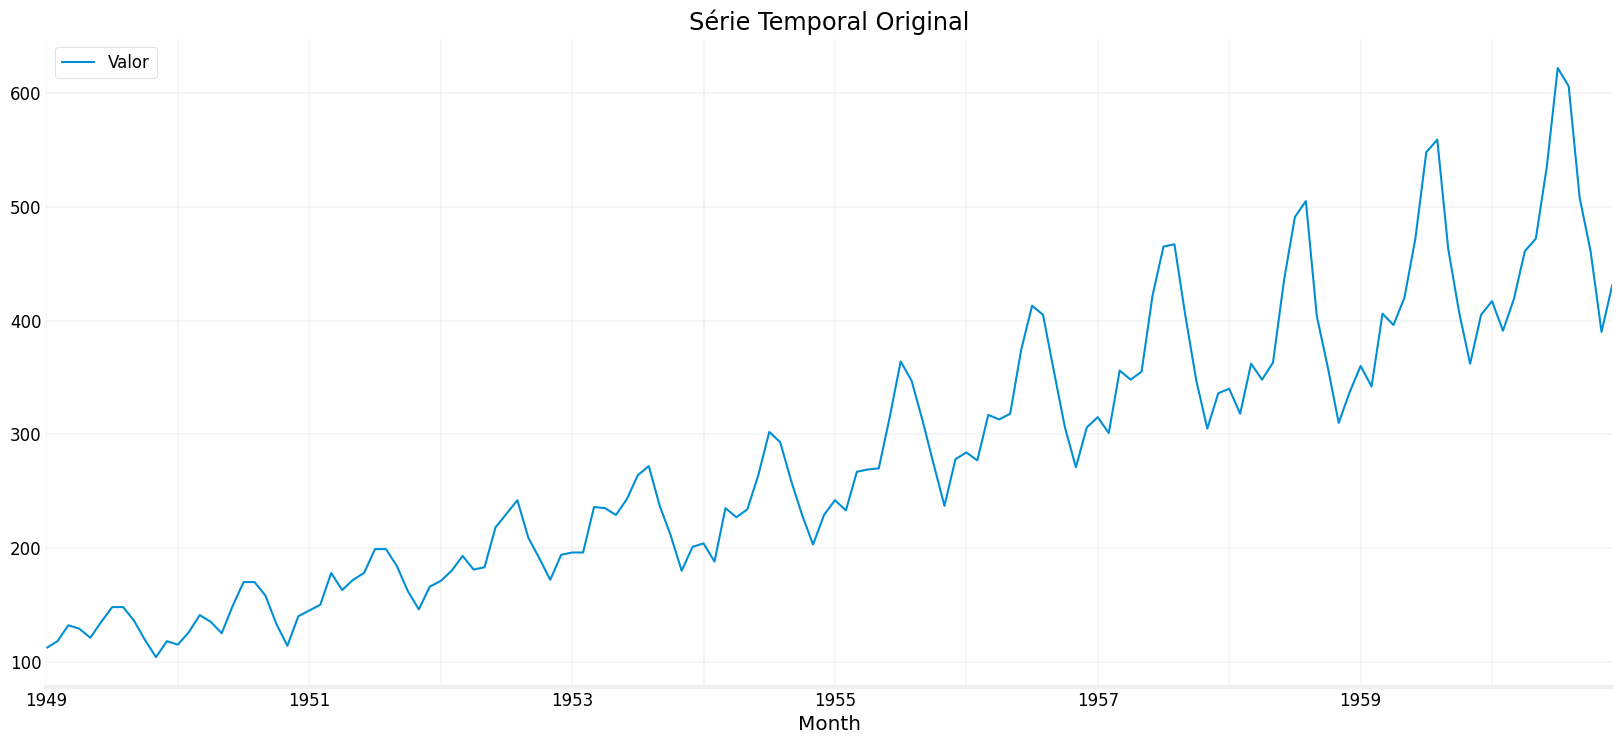

In [4]:
# Leitura do arquivo de dados
# Certifique-se de que o arquivo 'Passageiros.csv' está no mesmo diretório deste notebook.
try:
    MinhaSerieTemporal = pd.read_csv('Passageiros.csv', index_col = 0)
except FileNotFoundError:
    print("Arquivo não encontrado! Usando dataset padrão do statsmodels para continuidade da aula.")
    import statsmodels.api as sm
    data = sm.datasets.get_rdataset("AirPassengers").data
    data['time'] = pd.date_range(start='1949-01-01', periods=len(data), freq='M')
    data.set_index('time', inplace=True)
    MinhaSerieTemporal = pd.DataFrame(data['value'])

# Ajuste do índice para formato DateTime
MinhaSerieTemporal.index = pd.to_datetime(MinhaSerieTemporal.index)
MinhaSerieTemporal.columns = ['Valor']

# Visualização da série completa
MinhaSerieTemporal.plot(title='Série Temporal Original');

### 3. Separação: Treino e Teste

**Por que isso é importante?** Em séries temporais, nunca devemos embaralhar os dados (como fazemos em modelos de classificação/regressão tradicionais). A ordem cronológica importa. Usamos os dados passados (Treino) para prever o futuro (Teste) e simular como o modelo se sairia no mundo real.

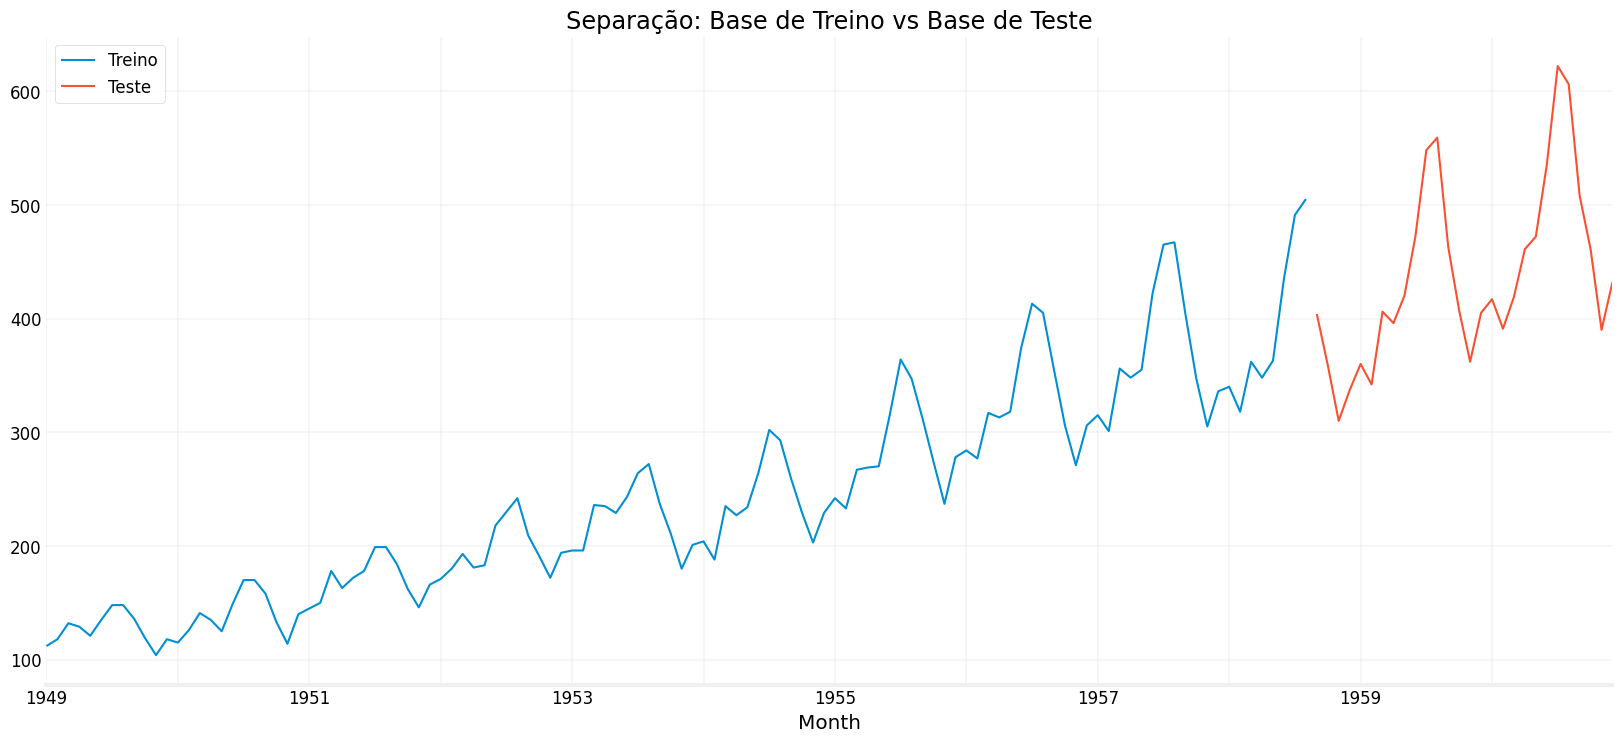

In [5]:
# Definição da proporção de dados para compor a base de teste
PercentualTeste = 20

# Cálculo do tamanho do período de testes
PeriodoTeste = int(PercentualTeste * len(MinhaSerieTemporal) / 100)

# Definição do DataFrame de treino e teste
TreinoDF = MinhaSerieTemporal.iloc[:-PeriodoTeste].copy()
TesteDF = MinhaSerieTemporal.iloc[-PeriodoTeste:].copy()

TreinoDF.rename(columns={'Valor': 'Treino'}, inplace=True)
TesteDF.rename(columns={'Valor': 'Teste'}, inplace=True)

# Exibe a série temporal destacando a separação
pd.concat([TreinoDF, TesteDF], axis = 1).plot(title='Separação: Base de Treino vs Base de Teste');

### 4. Análise Exploratória (Baseada apenas no Treino)

Vamos realizar os testes apenas na base de treino para evitar vazamento de dados (*data leakage*).

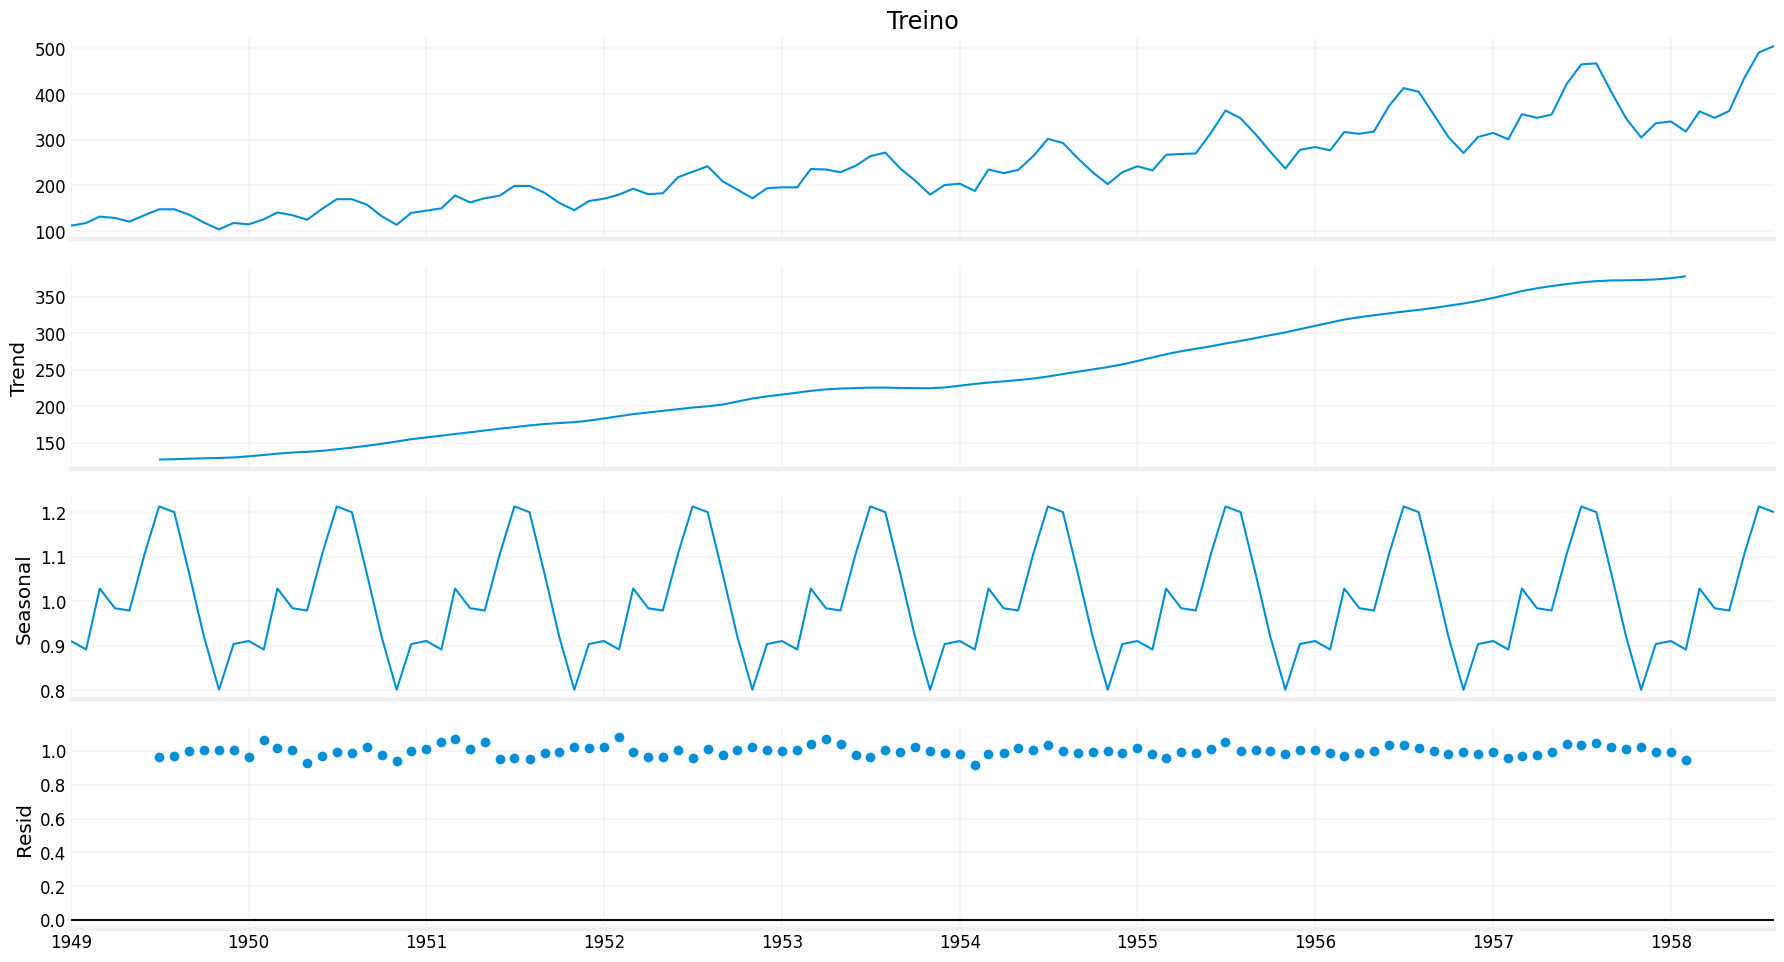

In [6]:
# Decomposição aditiva da série temporal de treino
PeriodoSazonal = 12     # Sazonalidade anual

Decomposicao = seasonal_decompose(TreinoDF['Treino'], model="multiplicative", period=PeriodoSazonal)
fig = Decomposicao.plot()
fig.set_size_inches(18, 10)
plt.show()

In [7]:
# Teste ADF para verificar estacionariedade
print("--- Teste ADF na Série Original (Treino) ---")
ad_fuller_result = adfuller(TreinoDF['Treino'])
print(f'Estatística ADF: {ad_fuller_result[0]:2.4f}')
print(f'p-value:         {ad_fuller_result[1]*100: 2.4f} %')
print("Se p-value > 5%, a série NÃO é estacionária.\n")

# Aplicação de Diferenciação
OrdemDif = 1
print(f"--- Teste ADF na Série Diferenciada (Ordem {OrdemDif}) ---")
ad_fuller_diff = adfuller(np.diff(TreinoDF['Treino'], n=OrdemDif))
print(f'Estatística ADF: {ad_fuller_diff[0]:2.4f}')
print(f'p-value:         {ad_fuller_diff[1]*100: 2.4f} %')

--- Teste ADF na Série Original (Treino) ---
Estatística ADF: -0.0766
p-value:          95.1717 %
Se p-value > 5%, a série NÃO é estacionária.

--- Teste ADF na Série Diferenciada (Ordem 1) ---
Estatística ADF: -2.7088
p-value:          7.2530 %


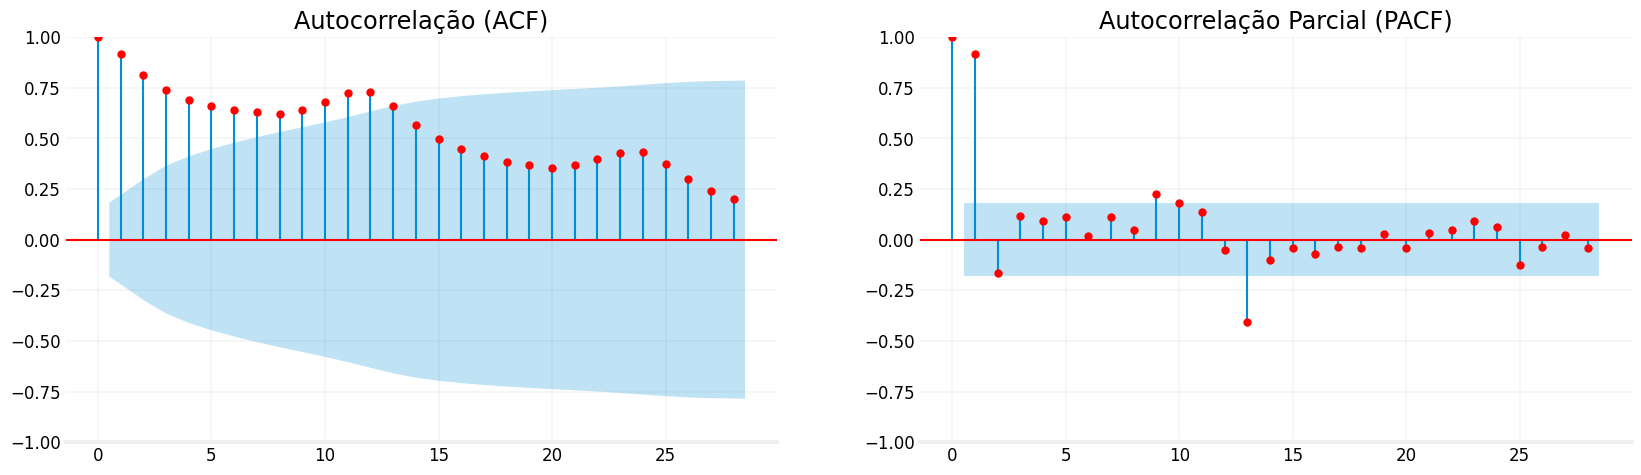

In [8]:
# Gráficos de Autocorrelação (ACF) e Autocorrelação Parcial (PACF) da série original
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(TreinoDF['Treino'], lags=28, title="Autocorrelação (ACF)", color="red", ax=axes[0])
plot_pacf(TreinoDF['Treino'], lags=28, title="Autocorrelação Parcial (PACF)", color="red", ax=axes[1])
plt.show()

### 5. Definindo as Métricas de Avaliação

Vamos criar uma função reutilizável para calcular todas as métricas solicitadas. 

* **MAE**: Erro Médio Absoluto (escala original).
* **MSE**: Erro Quadrático Médio (penaliza erros grandes).
* **RMSE**: Raiz do Erro Quadrático Médio (retorna à escala original).
* **MAPE**: Erro Percentual Absoluto Médio.
* **sMAPE**: Erro Percentual Absoluto Médio Simétrico (trata a assimetria do MAPE).
* **MASE**: Erro Escalado Médio Absoluto (compara o erro do modelo com o erro de um modelo ingênuo no treino; valores < 1 indicam que o modelo é melhor que o ingênuo).

In [9]:
def calcular_metricas(y_true, y_pred, y_train):
    """
    Calcula as principais métricas de erro para previsão de séries temporais.
    """
    y_true, y_pred, y_train = np.array(y_true), np.array(y_pred), np.array(y_train)
    
    # Cálculo base
    erros = y_true - y_pred
    
    mae = np.mean(np.abs(erros))
    mse = np.mean(erros**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(erros / y_true)) * 100
    
    # sMAPE
    smape = np.mean(2.0 * np.abs(erros) / (np.abs(y_true) + np.abs(y_pred))) * 100
    
    # MASE
    # Erro absoluto médio de um forecast ingênuo no conjunto de treino (passo 1)
    #mae_naive_train = np.mean(np.abs(np.diff(y_train)))
    #mase = mae / mae_naive_train if mae_naive_train != 0 else np.nan
    
    return pd.Series({
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'sMAPE (%)': smape
        #'MASE': mase
    })

### 6. Criando o Modelo Benchmark (Naive)

Um modelo Ingênuo (Naive) simplesmente prevê que o valor futuro será exatamente igual ao último valor observado na base de treino. É fundamental bater esse modelo para provar que a complexidade algorítmica do modelo estatístico vale a pena.

In [10]:
# O último valor conhecido no treinamento
ultimo_valor_treino = TreinoDF['Treino'].iloc[-1]

# O modelo Naive projeta esse valor para todo o horizonte de teste
PrevisoesNaive = np.repeat(ultimo_valor_treino, len(TesteDF))

# Avaliando o Benchmark
metricas_naive = calcular_metricas(TesteDF['Teste'], PrevisoesNaive, TreinoDF['Treino'])
print("--- Performance do Modelo Benchmark (Naive) ---")
print(metricas_naive.round(2))

--- Performance do Modelo Benchmark (Naive) ---
MAE             91.86
MSE          10656.71
RMSE           103.23
MAPE (%)        23.05
sMAPE (%)       20.18
dtype: float64


### 7. Otimização do Modelo ARMA (Grid Search)

Não vamos chutar parâmetros. Vamos testar combinações sistemáticas das ordens auto-regressivas (p) e médias móveis (q) e escolher o modelo que apresentar o menor critério de informação de Akaike (AIC).

In [11]:
pRange = 5
qRange = 5

Modelos = []
AIC_values = []

print("Iniciando busca pelos melhores parâmetros (Grid Search)...")
for p in range(pRange):
    for q in range(qRange):
        try:
            # d=0 pois estamos usando um modelo ARMA puro
            modelo = SARIMAX(TreinoDF['Treino'], order=(p, 0, q), enforce_stationarity=False, enforce_invertibility=False)
            resultado = modelo.fit(disp=False)
            
            Modelos.append(f'ARMA({p},{q})')
            AIC_values.append(resultado.aic)
        except:
            continue

# Organizando os resultados
ModelosAIC = pd.DataFrame({'Modelo': Modelos, 'AIC': AIC_values})
ModelosAIC = ModelosAIC.sort_values(by='AIC').reset_index(drop=True)

print("\nTop 5 Modelos pelo critério AIC:")
display(ModelosAIC.head())

Iniciando busca pelos melhores parâmetros (Grid Search)...


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py


Top 5 Modelos pelo critério AIC:


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Modelo,AIC
0,"ARMA(4,4)",1004.537915
1,"ARMA(1,4)",1011.866171
2,"ARMA(2,4)",1012.811889
3,"ARMA(3,4)",1014.349849
4,"ARMA(4,3)",1028.890193


### 8. Ajuste e Previsão com o Melhor Modelo

A partir da tabela acima, selecionamos os melhores parâmetros `p` e `q`.

In [12]:
# Com base na execução anterior, escolhemos a melhor combinação (vamos forçar 4,4 como no material original, ou pegar o topo do DataFrame)
best_p, best_q = 4, 4

print(f"Ajustando o modelo ARMA({best_p},{best_q}) final...")
modelo_final = SARIMAX(TreinoDF['Treino'], order=(best_p, 0, best_q))
resultado_final = modelo_final.fit(disp=False)

print(resultado_final.summary())

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Ajustando o modelo ARMA(4,4) final...
                               SARIMAX Results                                
Dep. Variable:                 Treino   No. Observations:                  116
Model:               SARIMAX(4, 0, 4)   Log Likelihood                -527.245
Date:                Wed, 26 Aug 2026   AIC                           1072.489
Time:                        16:38:11   BIC                           1097.271
Sample:                    01-01-1949   HQIC                          1082.549
                         - 08-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4877      0.764      0.639      0.523      -1.009       1.985
ar.L2          0.0045      0.170      0.026      0.979      -0.329       0.338
ar.L3         

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
# Realizando a previsão para o horizonte da base de teste
inicio = len(TreinoDF)
fim = len(TreinoDF) + len(TesteDF) - 1
PrevisoesARMA = resultado_final.predict(start=inicio, end=fim, dynamic=False)

# Montagem do DataFrame para os gráficos
PrevisoesDF = pd.DataFrame(index=TesteDF.index)
PrevisoesDF['Previsão ARMA'] = PrevisoesARMA.values
PrevisoesDF['Previsão Naive'] = PrevisoesNaive

### 9. Comparativo Final e Métricas

Por fim, plotamos as linhas para observação visual e calculamos o quadro comparativo de métricas para entender a real utilidade do modelo.

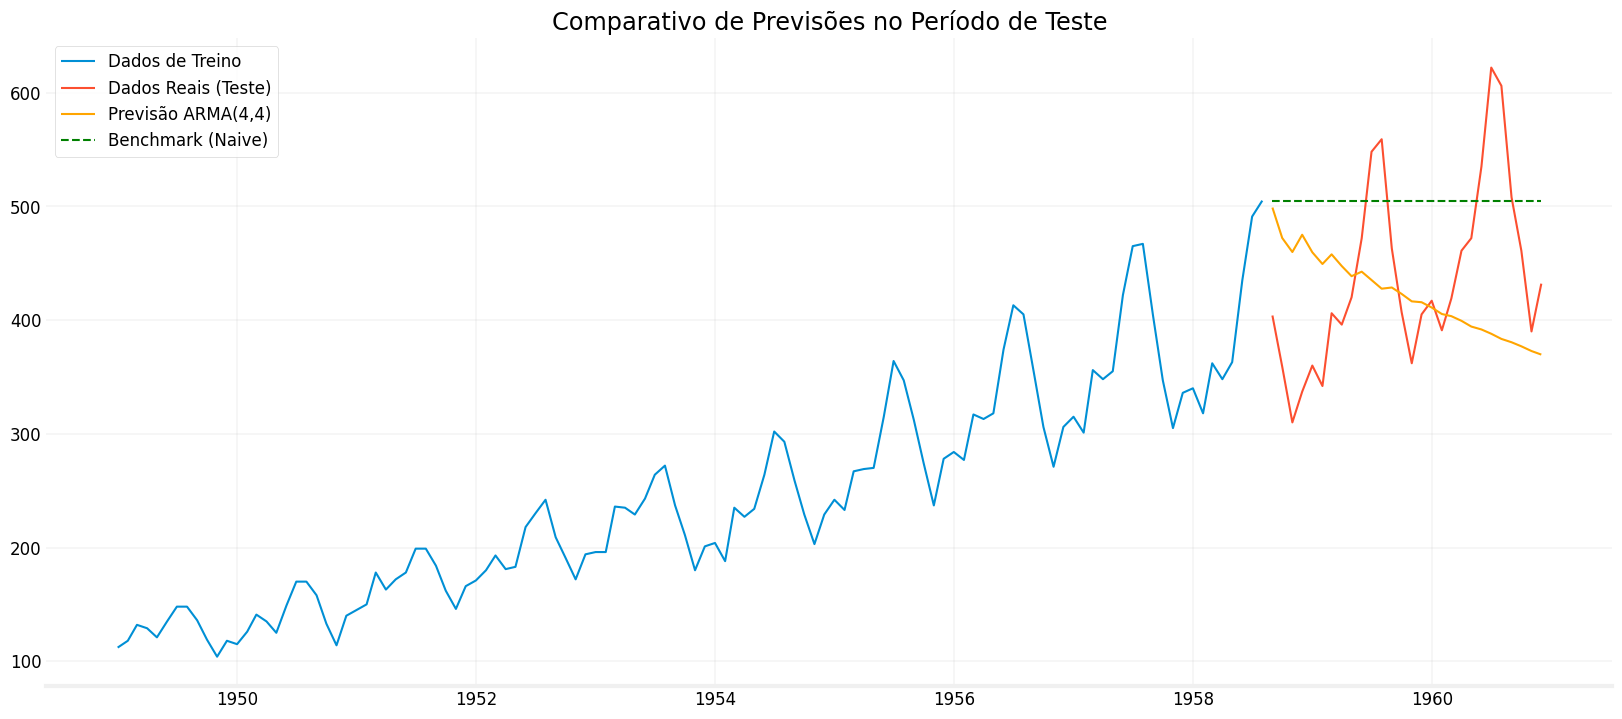

In [14]:
# Plotando Treino, Teste real, Previsão ARMA e Previsão Naive
plt.figure(figsize=(18, 8))
plt.plot(TreinoDF.index, TreinoDF['Treino'], label='Dados de Treino')
plt.plot(TesteDF.index, TesteDF['Teste'], label='Dados Reais (Teste)')
plt.plot(PrevisoesDF.index, PrevisoesDF['Previsão ARMA'], label=f'Previsão ARMA({best_p},{best_q})', color='orange')
plt.plot(PrevisoesDF.index, PrevisoesDF['Previsão Naive'], label='Benchmark (Naive)', color='green', linestyle='--')
plt.title('Comparativo de Previsões no Período de Teste')
plt.legend()
plt.show()

In [15]:
# Cálculo das métricas para o ARMA
metricas_arma = calcular_metricas(TesteDF['Teste'], PrevisoesDF['Previsão ARMA'], TreinoDF['Treino'])

# Exibição do Dataframe comparativo
Comparativo = pd.DataFrame({
    'Modelo Benchmark (Naive)': metricas_naive,
    f'Modelo ARMA({best_p},{best_q})': metricas_arma
})

print("\n=== RESULTADOS DA AVALIAÇÃO ===")
display(Comparativo.round(3))



=== RESULTADOS DA AVALIAÇÃO ===


,Modelo Benchmark (Naive),"Modelo ARMA(4,4)"
MAE,91.857,81.436
MSE,10656.714,10303.277
RMSE,103.231,101.505
MAPE (%),23.046,18.389
sMAPE (%),20.179,18.483
